In [ ]:
import pandas as pd
import os
from random import random
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
import keras
from keras import layers, models, ops
from keras.callbacks import EarlyStopping
from datetime import timedelta
from keras.models import load_model


os.environ["KERAS_BACKEND"] = "torch" 

In [2]:
os.chdir("..")

In [3]:
# from src.feature_engineering import apply_label_encoding_nn

In [4]:
train = pd.read_parquet('data/train_sales_data.parquet')
test = pd.read_parquet('data/test_sales_data.parquet')

# On supprime l'année 2013 car on va utiliser les lags à un an
def delete_2013(df):
    return df[df['year'] != 2013]

train = delete_2013(train)
test = delete_2013(test)

In [5]:
train.columns

Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'city',
       'state', 'store_type', 'cluster', 'oil_price', 'oil_price_trend_30',
       'oil_price_trend_60', 'oil_price_lag_8w', 'oil_price_lag_8w_trend_30',
       'oil_price_lag_8w_trend_60', 'holiday_type', 'is_holiday_local',
       'is_holiday_regional', 'is_holiday_national', 'day_of_week', 'month',
       'year', 'is_weekend', 'is_payday', 'month_sin', 'month_cos', 'day_sin',
       'day_cos', 'is_earthquake_impact', 'days_to_christmas', 'sales_lag_1',
       'sales_lag_2', 'sales_lag_3', 'sales_lag_7', 'sales_lag_14',
       'sales_lag_28', 'sales_lag_56', 'sales_lag_364', 'rolling_mean_7',
       'rolling_mean_28', 'log_sales', 'rolling_std_7', 'is_store_closed',
       'is_family_unactive', 'is_store_closed_lag_1',
       'is_family_unactive_lag_1'],
      dtype='object')

In [7]:
train.isnull().sum()

id                           0
date                         0
store_nbr                    0
family                       0
sales                        0
onpromotion                  0
city                         0
state                        0
store_type                   0
cluster                      0
oil_price                    0
oil_price_trend_30           0
oil_price_trend_60           0
oil_price_lag_8w             0
oil_price_lag_8w_trend_30    0
oil_price_lag_8w_trend_60    0
holiday_type                 0
is_holiday_local             0
is_holiday_regional          0
is_holiday_national          0
day_of_week                  0
month                        0
year                         0
is_weekend                   0
is_payday                    0
month_sin                    0
month_cos                    0
day_sin                      0
day_cos                      0
is_earthquake_impact         0
days_to_christmas            0
sales_lag_1                  0
sales_la

In [ ]:
def time_series_expanding_window(df, n_test_days=56, n_splits=5):
    print(f"Preparation de la validation croisee : {n_splits} splits de {n_test_days} jours.")
    
    unique_dates = np.sort(df['date'].unique())
    total_days = len(unique_dates)
    
    if (n_splits * n_test_days) >= total_days:
        raise ValueError(f"Pas assez de donnees pour {n_splits} splits.")

    splits = []
    
    for i in range(n_splits):
        end_test_idx = total_days - (i * n_test_days)
        start_test_idx = end_test_idx - n_test_days
        
        train_dates = unique_dates[:start_test_idx]
        val_dates = unique_dates[start_test_idx:end_test_idx]
        
        train_indices = df[df['date'].isin(train_dates)].index
        val_indices = df[df['date'].isin(val_dates)].index
        
        splits.insert(0, (train_indices, val_indices))
        
        print(f"Split {n_splits - i}: Train jusqu'au {str(train_dates[-1])[:10]}, "
              f"Val du {str(val_dates[0])[:10]} au {str(val_dates[-1])[:10]}")

    return splits


def apply_label_encoding_nn(df, cols, encoders_dict=None):
    df_encoded = df.copy()
    is_train = encoders_dict is None
    new_encoders = {}

    print(f"Shape initiale du DataFrame: {df_encoded.shape}")

    for col in cols:
        df_encoded[col] = df_encoded[col].astype(str)

        if is_train:
            le = LabelEncoder()
            
            # Construire le vocabulaire
            vocab = df_encoded[col].astype(str).unique().tolist()
            vocab.append("__UNK__")
            
            # Fit sur le vocabulaire
            le.fit(vocab)
            
            # Transform uniquement les vraies données
            df_encoded[f"label_{col}"] = le.transform(df_encoded[col])
            
            new_encoders[col] = le

            n_unique = len(le.classes_)
            emb_dim = min(50, (n_unique + 1) // 2)
            print(f"[TRAIN] Col: {col} | Uniques: {n_unique} | Embedding dim suggere: {emb_dim}")

        else:
            if col not in encoders_dict:
                print(f"Colonne {col} absente du dictionnaire d'encodeurs.")
                continue
                
            le = encoders_dict[col]
            
            # Gestion des catégories inconnues dans le test
            # On mappe les nouvelles valeurs vers une catégorie spécifique ou on utilise transform
            known_classes = set(le.classes_)
            df_encoded[col] = df_encoded[col].apply(lambda x: x if x in known_classes else "__UNK__")
            
            df_encoded[f'label_{col}'] = le.transform(df_encoded[col])
            print(f"[TEST] Col: {col} | Encodage applique avec succès")

        df_encoded = df_encoded.drop(columns=[col])
    
    print(f"Shape finale du DataFrame: {df_encoded.shape}")

    return df_encoded, (new_encoders if is_train else encoders_dict)


def apply_scaling_nn(df, cols_to_scale, scalers_dict=None):
    """
    Applique le StandardScaling sur les colonnes numeriques.
    Gere le fit sur train et le transform sur test pour eviter le leakage.
    """
    df_scaled = df.copy()
    is_train = scalers_dict is None
    new_scalers = {}

    for col in cols_to_scale:
        if col not in df_scaled.columns:
            continue
            
        if is_train:
            # Mode APPRENTISSAGE
            scaler = StandardScaler()
            # Reshape necessaire pour sklearn (-1, 1)
            df_scaled[col] = scaler.fit_transform(df_scaled[[col]])
            new_scalers[col] = scaler
            print(f"[TRAIN] Scaling de {col} : Moyenne={scaler.mean_[0]:.2f}, Ecart-type={scaler.scale_[0]:.2f}")
        else:
            # Mode APPLICATION
            if col in scalers_dict:
                scaler = scalers_dict[col]
                df_scaled[col] = scaler.transform(df_scaled[[col]])
            else:
                print(f"Scaler manquant pour {col}")

    return df_scaled, (new_scalers if is_train else scalers_dict)


def create_3d_tensors(df, cat_cols, window_past=90, window_future=56, step=1):

    X_past_final, X_future_final, Y_final, weights_final = [], [], [], []
    cat_values = {col: [] for col in cat_cols}

    cols_past = [
        'onpromotion', 'oil_price_lag_8w', 'oil_price_lag_8w_trend_30',
        'sales_lag_1', 'sales_lag_2', 'sales_lag_3', 'sales_lag_7', 
        'sales_lag_28', 'sales_lag_364', 'rolling_mean_7', 'rolling_mean_28', 
        'rolling_std_7', 'is_store_closed_lag_1', 'is_family_unactive_lag_1',
        'month_sin', 'month_cos', 'day_sin', 'day_cos', 'is_weekend', 'is_payday',
        "is_earthquake_impact", 'is_holiday_local', 'is_holiday_regional', 
        'is_holiday_national', 'days_to_christmas'
    ]
    cols_future = [
        'onpromotion', 'is_holiday_local', 'is_holiday_regional', 
        'is_holiday_national', 'month_sin', 'month_cos', 'day_sin', 
        'day_cos', 'is_weekend', 'is_payday', 'days_to_christmas', 
        "is_earthquake_impact"
    ]

    grouped = df.groupby(['label_store_nbr', 'label_family'])

    for name, group in grouped:

        group_values = group.sort_values('date')
        past_arr = group_values[cols_past].values
        future_arr = group_values[cols_future].values
        target_arr = group_values['log_sales'].values

        # 1 si ouvert/actif, 0 sinon
        weight_arr = ((group_values['is_store_closed'] == 0) & 
                      (group_values['is_family_unactive'] == 0)).astype(float).values
        
        static_cats = {col: group_values[f'label_{col}'].iloc[0] for col in cat_cols}

        n_obs = len(group_values)
        for i in range(0, n_obs - window_past - window_future + 1, step):

            X_past_final.append(past_arr[i : i + window_past])
            X_future_final.append(future_arr[i + window_past : i + window_past + window_future])
            Y_final.append(target_arr[i + window_past : i + window_past + window_future])
            weights_final.append(weight_arr[i + window_past : i + window_past + window_future])
            
            for col in cat_cols:
                cat_values[col].append(static_cats[col])

    X_list = [
        np.array(X_past_final, dtype='float32'), 
        np.array(X_future_final, dtype='float32')
    ]

    for col in cat_cols:
        X_list.append(np.array(cat_values[col], dtype='int32'))

    return X_list, np.array(Y_final, dtype='float32'), np.array(weights_final, dtype='float32')


def build_mimo_lstm(shape_past, shape_future, encoders, cat_cols, window_future=56):
    # Entrées pour les variables catégorielles avec embeddings
    cat_inputs = []
    cat_embeddings = []
    
    for col in cat_cols:
        n_unique = len(encoders[col].classes_)
        emb_dim = min(50, (n_unique + 1) // 2)
        
        inp = layers.Input(shape=(1,), name=f"input_{col}")
        emb = layers.Embedding(input_dim=n_unique, output_dim=emb_dim, name=f"emb_{col}")(inp)
        emb = layers.Flatten()(emb)
        
        cat_inputs.append(inp)
        cat_embeddings.append(emb)
    
    concat_cats = layers.Concatenate()(cat_embeddings)
    # Répéter pour les 56 jours du futur
    cats_repeated = layers.RepeatVector(window_future)(concat_cats)

    # Branche passé (LSTM)
    input_past = layers.Input(shape=shape_past, name="input_past")
    lstm_out = layers.LSTM(64, return_sequences=False)(input_past)
    past_repeated = layers.RepeatVector(window_future)(lstm_out)

    # Branche future (Contexte)
    input_future = layers.Input(shape=shape_future, name="input_future")

    # Fusion et sortie
    combined = layers.Concatenate()([past_repeated, input_future, cats_repeated])
    
    # Couches denses appliquées à chaque pas de temps
    x = layers.TimeDistributed(layers.Dense(64, activation='relu'))(combined)
    x = layers.TimeDistributed(layers.Dense(1))(x)

    # Reshape pour passer de (batch, 56, 1) à (batch, 56)
    output = layers.Reshape((window_future,))(x)

    model = models.Model(inputs=[input_past, input_future] + cat_inputs, outputs=output)
    
    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )
    
    return model

# Dans cette version suivante, on ajoute :
# - Une deuxième couche LSTM dans la branche passé pour capturer des patterns plus complexes.
# - Des couches denses supplémentaires dans le décodeur pour une meilleure capacité d'apprentissage.
# - Des Dropout pour réduire le surapprentissage.

def build_mimo_lstm_advanced(shape_past, shape_future, encoders, cat_cols, window_future=56, dropout=0.2):

    # Embeddings (Identité)
    cat_inputs, cat_embeddings = [], []
    for col in cat_cols:
        n_unique = len(encoders[col].classes_)
        emb_dim = min(50, (n_unique + 1) // 2)
        inp = layers.Input(shape=(1,), name=f"input_{col}")
        emb = layers.Embedding(input_dim=n_unique, output_dim=emb_dim)(inp)
        emb = layers.Flatten()(emb)
        cat_inputs.append(inp)
        cat_embeddings.append(emb)
    
    concat_cats = layers.Concatenate()(cat_embeddings)
    cats_repeated = layers.RepeatVector(window_future)(concat_cats)

    # Branche Passé : Double LSTM
    input_past = layers.Input(shape=shape_past, name="input_past")
    
    # Premier LSTM : On garde les séquences pour que le suivant puisse "lire"
    x_past = layers.LSTM(64, return_sequences=True)(input_past)
    x_past = layers.Dropout(dropout)(x_past)
    
    # Second LSTM : On extrait le résumé final
    lstm_out = layers.LSTM(32, return_sequences=False)(x_past)
    lstm_out = layers.Dropout(dropout)(lstm_out)
    
    # On répète le résumé pour chaque pas futur
    past_repeated = layers.RepeatVector(window_future)(lstm_out)

    # Branche Future & Fusion
    input_future = layers.Input(shape=shape_future, name="input_future")

    combined = layers.Concatenate()([past_repeated, input_future, cats_repeated])
    
    # Décodeur Dense
    x = layers.TimeDistributed(layers.Dense(64, activation='relu'))(combined)
    x = layers.TimeDistributed(layers.Dropout(dropout))(x)
    x = layers.TimeDistributed(layers.Dense(32, activation='relu'))(x) # Couche supplémentaire
    
    # Si tes log_sales descendent sous 0 (ventes < 1), retire activation='relu'
    x = layers.TimeDistributed(layers.Dense(1))(x) 

    output = layers.Reshape((window_future,))(x)

    model = models.Model(inputs=[input_past, input_future] + cat_inputs, outputs=output)
    
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model


def evaluate_model_simple(y_true, y_pred, weights):
    y_pred_clipped = np.maximum(y_pred, 0)
    n_active = np.sum(weights)
    
    if n_active == 0: 
        return {"mae": np.nan, "rmse": np.nan, "rmsle": np.nan}
    
    mae = np.sum(np.abs(y_true - y_pred_clipped) * weights) / n_active
    rmse = np.sqrt(np.sum(((y_true - y_pred_clipped) ** 2) * weights) / n_active)
    
    log_true = np.log1p(np.maximum(y_true, 0))
    log_pred = np.log1p(y_pred_clipped)
    rmsle = np.sqrt(np.sum(((log_true - log_pred) ** 2) * weights) / n_active)
    
    return {"mae": mae, "rmse": rmse, "rmsle": rmsle}

Modèle simple :

In [ ]:
cv_splits = time_series_expanding_window(train, n_test_days=56, n_splits=3)
results_cv = []

early_stop = EarlyStopping(
    monitor='loss', # On surveille la perte sur le train (car la val_loss sur 1 seul bloc est instable)
    patience=2,     # Si pendant 2 époques ça ne s'améliore pas, on arrête
    restore_best_weights=True
)

cols_to_scale = [
    'onpromotion', 'oil_price_lag_8w', 'oil_price_lag_8w_trend_30', 
    'days_to_christmas', 'sales_lag_1', 'sales_lag_2', 'sales_lag_3', 
    'sales_lag_7', 'sales_lag_28', 'sales_lag_364', 'rolling_mean_7', 
    'rolling_mean_28', 'rolling_std_7'
]

cols_to_encode = ['family', 'store_nbr', 'cluster', 'store_type', "holiday_type"]


for i, (train_idx, val_idx) in enumerate(cv_splits):
    print(f"\n--- SPLIT {i+1} ---")
    
    df_fold_train = train.loc[train_idx].copy()
    df_fold_val = train.loc[val_idx].copy()
    
    df_fold_train, encoders = apply_label_encoding_nn(df_fold_train, cols_to_encode)
    df_fold_val, _ = apply_label_encoding_nn(df_fold_val, cols_to_encode, encoders_dict=encoders)
    df_fold_train, scalers = apply_scaling_nn(df_fold_train, cols_to_scale)
    df_fold_val, _ = apply_scaling_nn(df_fold_val, cols_to_scale, scalers_dict=scalers)
    
    # Train tensors (jouer sur step pour sauver de la RAM si besoin)
    X_train_list, y_train_3d, w_train_3d = create_3d_tensors(df_fold_train, cols_to_encode, step=7)
    
    # Val tensors avec contexte
    last_90 = df_fold_train.groupby(['label_store_nbr', 'label_family']).tail(90)
    df_val_ctx = pd.concat([last_90, df_fold_val]).sort_values(['label_store_nbr', 'label_family', 'date'])
    X_val_list, y_val_3d, w_val_3d = create_3d_tensors(df_val_ctx, cols_to_encode, step=56)

    model = build_mimo_lstm(
        X_train_list[0].shape[1:], 
        X_train_list[1].shape[1:], 
        encoders, 
        cols_to_encode
        )
    
    model.fit(
        X_train_list, y_train_3d, 
        sample_weight=w_train_3d.mean(axis=1), 
        epochs=5, 
        batch_size=512, 
        callbacks=[early_stop], 
        verbose=1
    )
    
    y_pred = model.predict(X_val_list)
    
    # Evaluation propre
    metrics = evaluate_model_simple(y_val_3d.flatten(), y_pred.flatten(), w_val_3d.flatten())
    print(f"RMSLE sur le split {i+1} : {metrics['rmsle']:.4f}")
    results_cv.append(metrics)

# Moyenne finale
final_rmsle = np.nanmean([r['rmsle'] for r in results_cv])
print(f"\nRMSLE Moyen sur 3 splits : {final_rmsle:.4f}")

Preparation de la validation croisee : 3 splits de 56 jours.
Split 3: Train jusqu'au 2017-04-25, Val du 2017-04-26 au 2017-06-20
Split 2: Train jusqu'au 2017-02-28, Val du 2017-03-01 au 2017-04-25
Split 1: Train jusqu'au 2017-01-03, Val du 2017-01-04 au 2017-02-28

--- SPLIT 1 ---
Shape initiale du DataFrame: (1953072, 47)
[TRAIN] Col: family | Uniques: 34 | Embedding dim suggere: 17
[TRAIN] Col: store_nbr | Uniques: 55 | Embedding dim suggere: 28
[TRAIN] Col: cluster | Uniques: 18 | Embedding dim suggere: 9
[TRAIN] Col: store_type | Uniques: 6 | Embedding dim suggere: 3
[TRAIN] Col: holiday_type | Uniques: 7 | Embedding dim suggere: 4
Shape finale du DataFrame: (1953072, 47)
Shape initiale du DataFrame: (99792, 47)
[TEST] Col: family | Encodage applique avec succès
[TEST] Col: store_nbr | Encodage applique avec succès
[TEST] Col: cluster | Encodage applique avec succès
[TEST] Col: store_type | Encodage applique avec succès
[TEST] Col: holiday_type | Encodage applique avec succès
Shape

KeyboardInterrupt: 

In [ ]:
results_cv

[{'mae': np.float32(0.43870497),
  'rmse': np.float32(0.576923),
  'rmsle': np.float32(0.21514794)},
 {'mae': np.float32(0.40959314),
  'rmse': np.float32(0.6001849),
  'rmsle': np.float32(0.23887113)},
 {'mae': np.float32(0.41856614),
  'rmse': np.float32(0.574634),
  'rmsle': np.float32(0.21834603)}]

On garde le modèle entrainé sur le dernier fold:

In [ ]:
model.save('model/mimo_lstm_model.keras')

Modèle un peu plus avancé:

In [ ]:
cv_splits = time_series_expanding_window(train, n_test_days=56, n_splits=3)
advanced_model_results_cv = []

early_stop = EarlyStopping(
    monitor='loss', # On surveille la perte sur le train (car la val_loss sur 1 seul bloc est instable)
    patience=2,     # Si pendant 2 époques ça ne s'améliore pas, on arrête
    restore_best_weights=True
)

cols_to_scale = [
    'onpromotion', 'oil_price_lag_8w', 'oil_price_lag_8w_trend_30', 
    'days_to_christmas', 'sales_lag_1', 'sales_lag_2', 'sales_lag_3', 
    'sales_lag_7', 'sales_lag_28', 'sales_lag_364', 'rolling_mean_7', 
    'rolling_mean_28', 'rolling_std_7'
]

cols_to_encode = ['family', 'store_nbr', 'cluster', 'store_type', "holiday_type"]


for i, (train_idx, val_idx) in enumerate(cv_splits):
    print(f"\n--- SPLIT {i+1} ---")
    
    df_fold_train = train.loc[train_idx].copy()
    df_fold_val = train.loc[val_idx].copy()
    
    df_fold_train, encoders = apply_label_encoding_nn(df_fold_train, cols_to_encode)
    df_fold_val, _ = apply_label_encoding_nn(df_fold_val, cols_to_encode, encoders_dict=encoders)
    df_fold_train, scalers = apply_scaling_nn(df_fold_train, cols_to_scale)
    df_fold_val, _ = apply_scaling_nn(df_fold_val, cols_to_scale, scalers_dict=scalers)
    
    # Train tensors (jouer sur step pour sauver de la RAM si besoin)
    X_train_list, y_train_3d, w_train_3d = create_3d_tensors(df_fold_train, cols_to_encode, step=7)
    
    # Val tensors avec contexte
    last_90 = df_fold_train.groupby(['label_store_nbr', 'label_family']).tail(90)
    df_val_ctx = pd.concat([last_90, df_fold_val]).sort_values(['label_store_nbr', 'label_family', 'date'])
    X_val_list, y_val_3d, w_val_3d = create_3d_tensors(df_val_ctx, cols_to_encode, step=56)

    advanced_model = build_mimo_lstm_advanced(
        X_train_list[0].shape[1:], 
        X_train_list[1].shape[1:], 
        encoders, 
        cols_to_encode, 
        dropout=0.2
        )
    
    advanced_model.fit(
        X_train_list, y_train_3d, 
        sample_weight=w_train_3d.mean(axis=1), 
        epochs=5, 
        batch_size=512, 
        callbacks=[early_stop], 
        verbose=1
    )
    
    y_pred = advanced_model.predict(X_val_list)
    
    # Evaluation propre
    metrics = evaluate_model_simple(y_val_3d.flatten(), y_pred.flatten(), w_val_3d.flatten())
    print(f"RMSLE sur le split {i+1} : {metrics['rmsle']:.4f}")
    advanced_model_results_cv.append(metrics)

# Moyenne finale
advanced_model_final_rmsle = np.nanmean([r['rmsle'] for r in advanced_model_results_cv])
print(f"\nRMSLE Moyen sur 3 splits : {advanced_model_final_rmsle:.4f}")

In [ ]:
advanced_model_results_cv

[{'mae': np.float32(0.43870497),
  'rmse': np.float32(0.576923),
  'rmsle': np.float32(0.21514794)},
 {'mae': np.float32(0.40959314),
  'rmse': np.float32(0.6001849),
  'rmsle': np.float32(0.23887113)},
 {'mae': np.float32(0.41856614),
  'rmse': np.float32(0.574634),
  'rmsle': np.float32(0.21834603)}]

On garde le modèle entrainé sur le dernier fold:

In [ ]:
advanced_model.save('model_/mimo_lstm_advanced_model.keras')

Entrainer le modèle le plus performant sur toutes les données. 

On repart des poids du meilleur des modèles enregistrés. Cela permettra de converger plus vite. Pour le nombre d'époques, on met ce qu'on a observé sur la cross validation (on ne peut plus avoir de early stopping). Donc si le modèle s'est stoppé à 3 époques pendant l'entrainement en cv, on met 3 époques ici. 

In [ ]:
# charge le meilleur modèle entre noramal et advanced et choisis le nombre d'époques
final_model = load_model('model/mimo_lstm_model.keras')
EPOCHS = 5

In [ ]:
# Filtrer sur les 2 dernières années pour économiser la RAM
max_date = train['date'].max()
start_date = max_date - timedelta(days=730)

print(f"Filtrage des données : du {start_date.date()} au {max_date.date()}")
train_reduced = train[train['date'] >= start_date].copy()

# Preprocessing
df_train_final, encoders_final = apply_label_encoding_nn(train_reduced, cols_to_encode)
df_train_final, scalers_final = apply_scaling_nn(df_train_final, cols_to_scale)

# Création des tenseurs
X_train_all, y_train_all, w_train_all = create_3d_tensors(
    df_train_final, 
    cols_to_encode, 
    step=7
)

print("\nFine-tuning final sur les 2 dernières années")
final_model.fit(
    X_train_all, y_train_all, 
    sample_weight=w_train_all.mean(axis=1),
    epochs=EPOCHS, 
    batch_size=512,
    verbose=1
)

c:\Users\leoco\Documents\cours\M2_MOSEF\time_series_deep_learning\Store_Sales_Time_Series_Forecasting\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 14 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Filtrage des données : du 2015-06-21 au 2017-06-20
Shape initiale du DataFrame: (1299078, 47)
[TRAIN] Col: family | Uniques: 33 | Embedding dim suggere: 17
[TRAIN] Col: store_nbr | Uniques: 54 | Embedding dim suggere: 27
[TRAIN] Col: cluster | Uniques: 17 | Embedding dim suggere: 9
[TRAIN] Col: store_type | Uniques: 5 | Embedding dim suggere: 3
[TRAIN] Col: holiday_type | Uniques: 6 | Embedding dim suggere: 3
Shape finale du DataFrame: (1299078, 47)
[TRAIN] Scaling de onpromotion : Moyenne=4.86, Ecart-type=16.70
[TRAIN] Scaling de oil_price_lag_8w : Moyenne=46.29, Ecart-type=7.44
[TRAIN] Scaling de oil_price_lag_8w_trend_30 : Moyenne=-0.06, Ecart-type=5.07
[TRAIN] Scaling de days_to_christmas : Moyenne=182.74, Ecart-type=105.21
[TRAIN] Scaling de sales_lag_1 : Moyenne=450.42, Ecart-type=1297.44
[TRAIN] Scaling de sales_lag_2 : Moyenne=450.32, Ecart-type=1297.27
[TRAIN] Scaling de sales_lag_3 : Moyenne=450.00, Ecart-type=1296.43
[TRAIN] Scaling de sales_lag_7 : Moyenne=449.70, Ecart-typ

In [ ]:
final_model.save('model/mimo_lstm_final_model.keras')

Evaluer sur le test. 

In [ ]:
# Préparation du jeu test (scaling/encoding avec les paramètres du train)
df_test_proc, _ = apply_label_encoding_nn(test, cols_to_encode, encoders_dict=encoders_final)
df_test_proc, _ = apply_scaling_nn(df_test_proc, cols_to_scale, scalers_dict=scalers_final)

# Récupération du contexte passé (90 derniers jours du train)
last_90_train = df_train_final.groupby(['label_store_nbr', 'label_family']).tail(90)

# Concaténation [Passé (90j) | Futur (56j du test)]
df_test_ctx = pd.concat([last_90_train, df_test_proc]).sort_values(['label_store_nbr', 'label_family', 'date'])

# Création des tenseurs pour le test (step=56 pour avoir 1 fenêtre par série)
X_test_list, y_test_true, w_test_weights = create_3d_tensors(
    df_test_ctx, 
    cols_to_encode, 
    window_past=90, 
    window_future=56, 
    step=56
)

# Prédiction
y_log_pred = final_model.predict(X_test_list)

# Conversion en ventes réelles
y_pred_final = np.expm1(y_log_pred)
y_pred_final = np.maximum(y_pred_final, 0)

y_true_final = np.expm1(y_test_true) # y_test_true est aussi en log

Shape initiale du DataFrame: (99792, 47)
[TEST] Col: family | Encodage applique avec succès
[TEST] Col: store_nbr | Encodage applique avec succès
[TEST] Col: cluster | Encodage applique avec succès
[TEST] Col: store_type | Encodage applique avec succès
[TEST] Col: holiday_type | Encodage applique avec succès
Shape finale du DataFrame: (99792, 47)
56/56 ━━━━━━━━━━━━━━━━━━━━ 18s 329ms/step


In [ ]:
# On aplatit pour l'évaluation
metrics_final = evaluate_model_simple(
    y_true_final.flatten(), 
    y_pred_final.flatten(), 
    w_test_weights.flatten()
)

print("\nPERFORMANCE FINALE SUR 56 JOURS")
print(f"MAE   : {metrics_final['mae']:.4f}")
print(f"RMSE  : {metrics_final['rmse']:.4f}")
print(f"RMSLE : {metrics_final['rmsle']:.4f}")


--- PERFORMANCE FINALE SUR 56 JOURS ---
MAE   : 99.5718
RMSE  : 361.1985
RMSLE : 0.5873


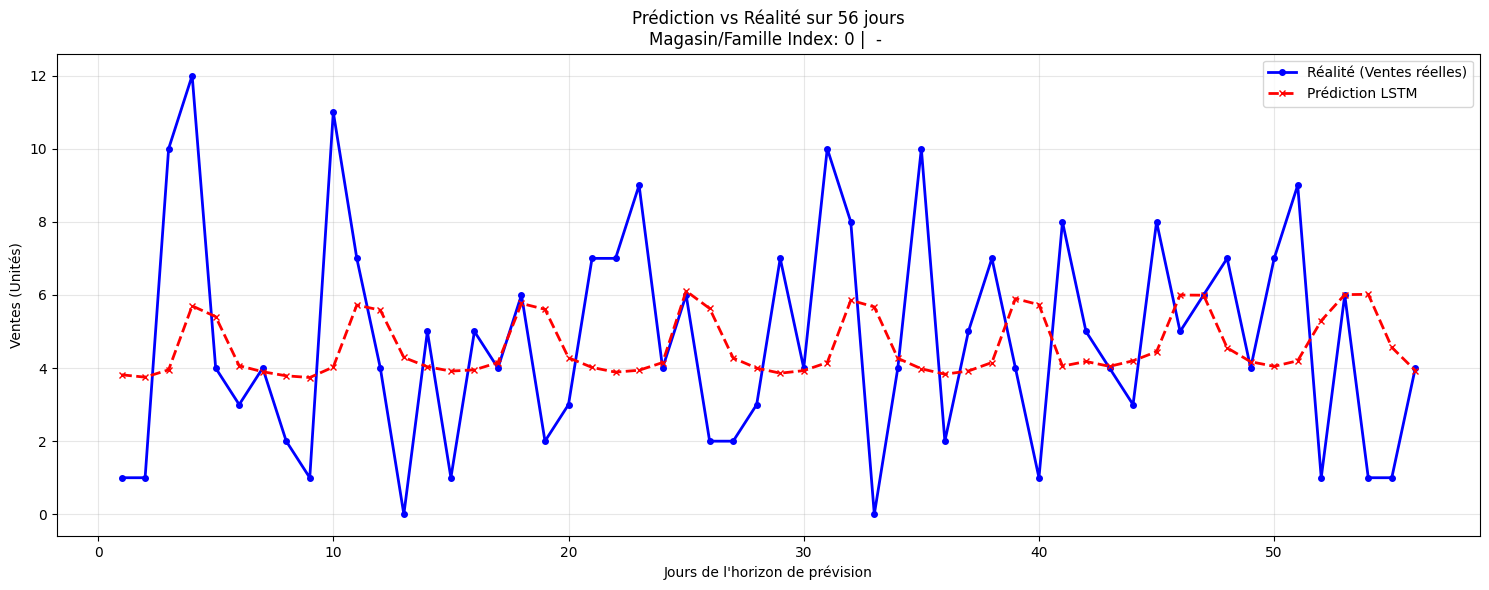

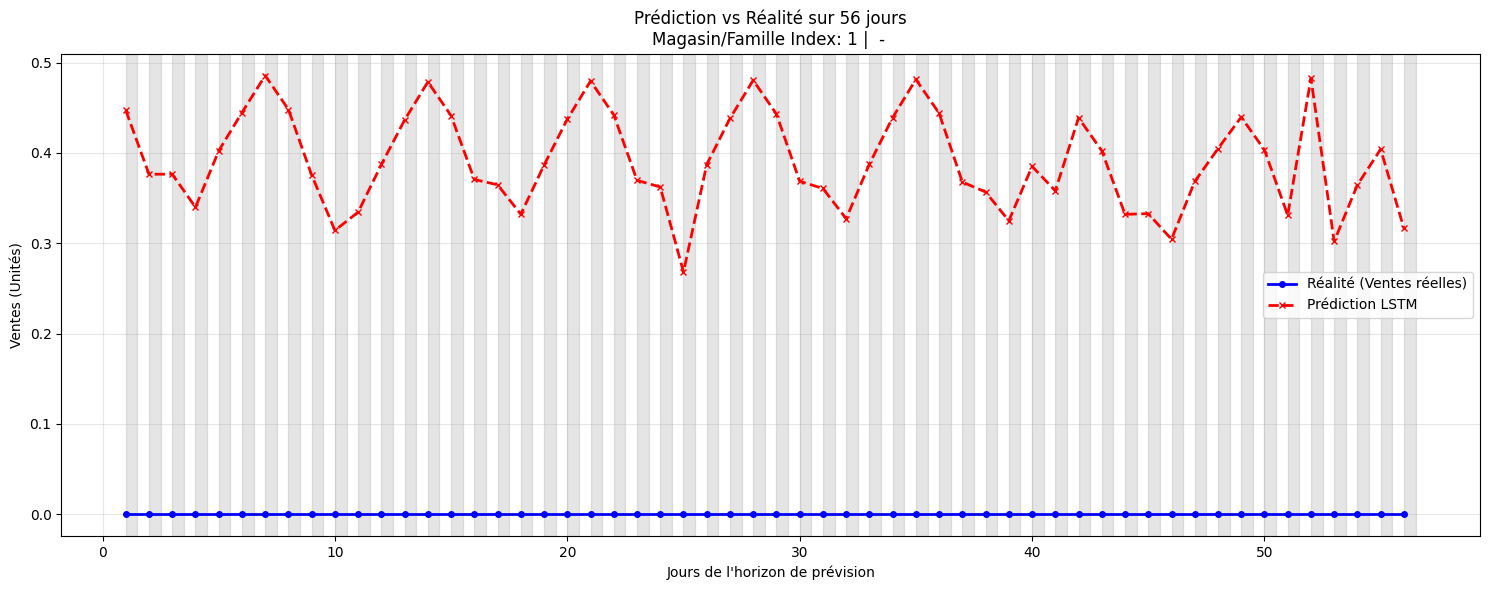

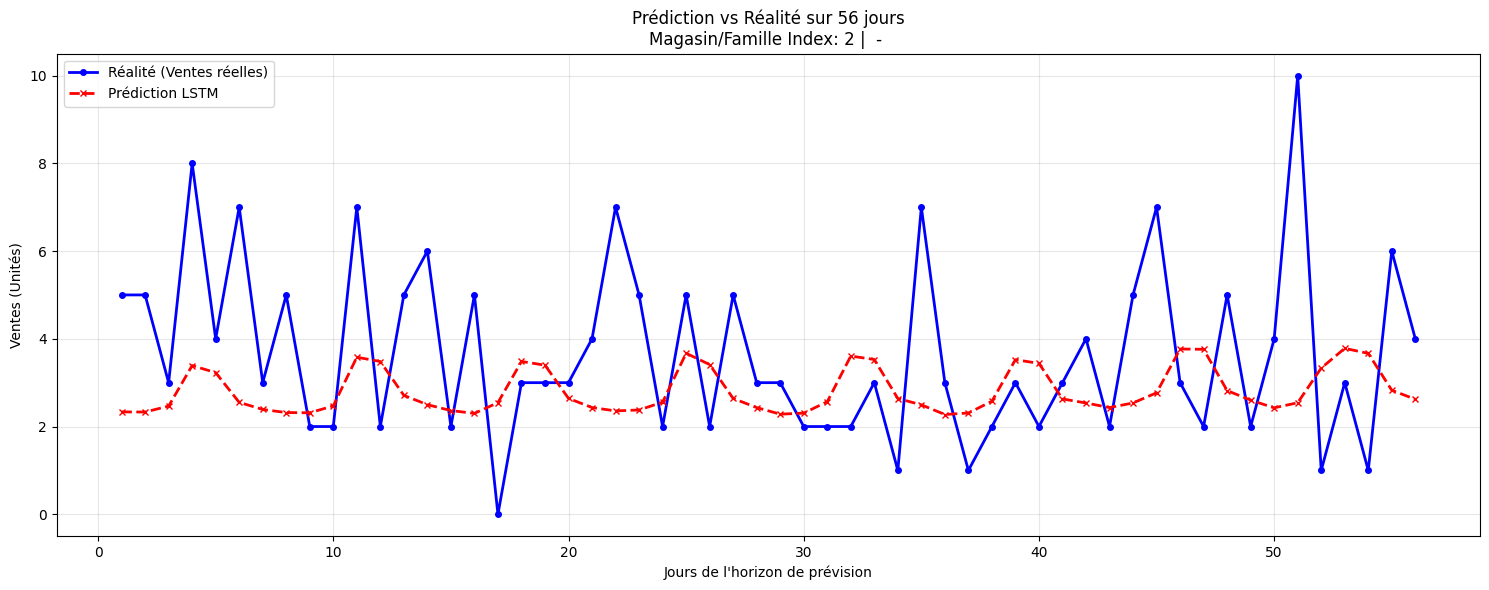

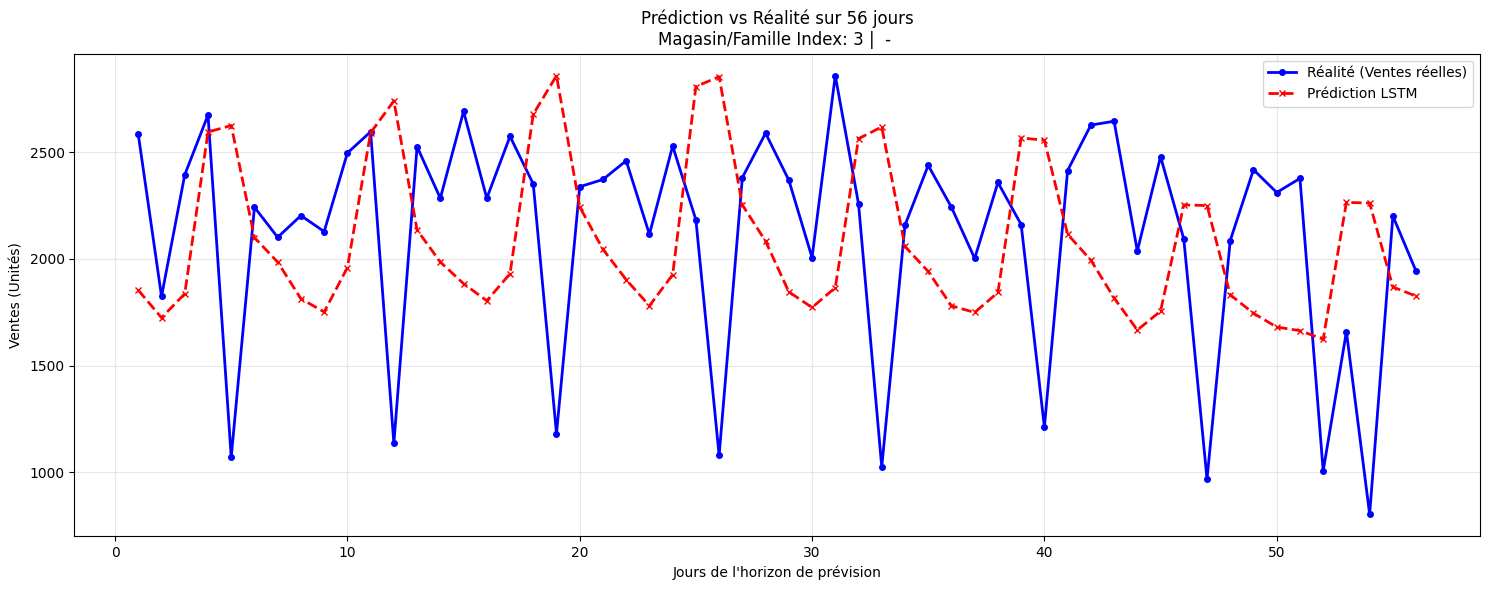

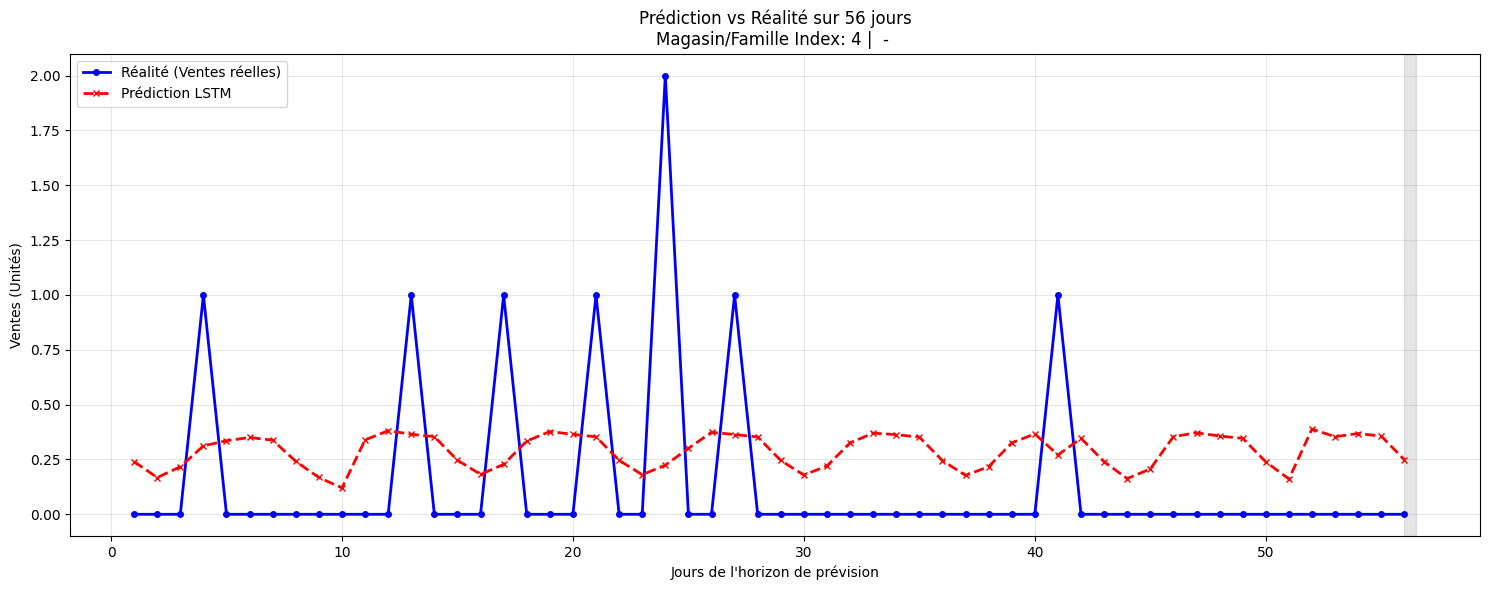

In [ ]:
def plot_prediction_vs_reality(y_true, y_pred, weights, series_idx=0, store_name="", family_name=""):
    """
    Trace la comparaison entre les ventes réelles et prédites pour une série donnée.
    y_true et y_pred doivent être de forme (N_series, 56)
    """
    # Extraction des données pour la série choisie
    true_series = y_true[series_idx]
    pred_series = y_pred[series_idx]
    active_mask = weights[series_idx]

    # Création de l'axe X (56 jours)
    days = np.arange(1, 57)

    plt.figure(figsize=(15, 6))
    
    # Tracer la réalité
    plt.plot(days, true_series, label='Réalité (Ventes réelles)', color='blue', linewidth=2, marker='o', markersize=4)
    
    # Tracer la prédiction
    plt.plot(days, pred_series, label='Prédiction LSTM', color='red', linestyle='--', linewidth=2, marker='x', markersize=4)

    # Griser les zones où le magasin était fermé (poids = 0)
    for i, active in enumerate(active_mask):
        if active == 0:
            plt.axvspan(i+1, i+1.5, color='gray', alpha=0.2)

    plt.title(f"Prédiction vs Réalité sur 56 jours\nMagasin/Famille Index: {series_idx} | {store_name} - {family_name}")
    plt.xlabel("Jours de l'horizon de prévision")
    plt.ylabel("Ventes (Unités)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Exemple de tracé pour 5 séries aléatoires
for idx_to_plot in range(5):
    plot_prediction_vs_reality(
        y_true_final, 
        y_pred_final, 
        w_test_weights, 
        series_idx=idx_to_plot
    )


Feature importance du LSTM (je ne sais pas si cette cellule marche)

In [ ]:
def plot_lstm_feature_importance(model, X_list, y_true, w_weights, cols_past, cols_future):
    # Calculer le score de base (Baseline)
    y_pred_base = model.predict(X_list, verbose=0)
    baseline_metrics = evaluate_model_simple(y_true.flatten(), y_pred_base.flatten(), w_weights.flatten())
    baseline_score = baseline_metrics['rmsle']
    
    importance_results = {}
    
    # Importance pour les variables du PASSÉ (Input 0)
    print("Calcul de l'importance pour les variables passées...")
    for i, col in enumerate(cols_past):
        X_temp = [np.copy(x) for x in X_list]
        # On mélange les données de la colonne i sur l'axe du temps
        save_col = X_temp[0][:, :, i].copy()
        np.random.shuffle(X_temp[0][:, :, i])
        
        y_pred = model.predict(X_temp, verbose=0)
        score = evaluate_model_simple(y_true.flatten(), y_pred.flatten(), w_weights.flatten())['rmsle']
        importance_results[f"Past_{col}"] = score - baseline_score
        
    # Importance pour les variables du FUTUR (Input 1)
    print("Calcul de l'importance pour les variables futures...")
    for i, col in enumerate(cols_future):
        X_temp = [np.copy(x) for x in X_list]
        np.random.shuffle(X_temp[1][:, :, i])
        
        y_pred = model.predict(X_temp, verbose=0)
        score = evaluate_model_simple(y_true.flatten(), y_pred.flatten(), w_weights.flatten())['rmsle']
        importance_results[f"Future_{col}"] = score - baseline_score

    # Création du Plot
    df_importance = pd.DataFrame(list(importance_results.items()), columns=['Feature', 'Importance'])
    df_importance = df_importance.sort_values(by='Importance', ascending=True)

    plt.figure(figsize=(10, 12))
    plt.barh(df_importance['Feature'], df_importance['Importance'], color='skyblue')
    plt.xlabel('Augmentation de l\'erreur (RMSLE) après permutation')
    plt.title('Importance des variables (Permutation Importance)')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


cols_past = [
    'onpromotion', 'oil_price_lag_8w', 'oil_price_lag_8w_trend_30',
    'sales_lag_1', 'sales_lag_2', 'sales_lag_3', 'sales_lag_7', 
    'sales_lag_28', 'sales_lag_364', 'rolling_mean_7', 'rolling_mean_28', 
    'rolling_std_7', 'is_store_closed_lag_1', 'is_family_unactive_lag_1',
    'month_sin', 'month_cos', 'day_sin', 'day_cos', 'is_weekend', 'is_payday'
]
cols_future = [
    'onpromotion', 'is_holiday_local', 'is_holiday_regional', 
    'is_holiday_national', 'month_sin', 'month_cos', 'day_sin', 
    'day_cos', 'is_weekend', 'is_payday', 'days_to_christmas'
]

plot_lstm_feature_importance(final_model, X_val_list, y_val_3d, w_val_3d, cols_past, cols_future)

NameError: name 'X_val_list' is not defined